### Imports

In [1]:
import os
from pathlib import Path
import numpy as np
import torch
import torchvision.models as models
from tifffile import TiffFile
from skimage.transform import resize
from scipy.ndimage import laplace
import scanpy as sc
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


### Paths and Configuration

In [2]:
base_dir = Path("C:/Users/mills/Desktop/Angione Lab/OC")
adata_path = base_dir / "OC_adata_hvg.h5ad"

output_dir = base_dir / "spatial_2"
output_dir.mkdir(exist_ok=True)

DAPI_FOLDER = base_dir / "DAPI"

Z_SLICE_FILES = [
    DAPI_FOLDER / f"HumanOvarianCancerPatient2Slice2_images_mosaic_DAPI_z{i}.tif"
    for i in range(7)
]

EMBEDDINGS_SAVE_PATH = output_dir / "OC_adata_hvg_cnn_embeddings.npy"
ADATA_SAVE_PATH = output_dir / "OC_adata_hvg_with_cnn.h5ad"

patch_size = 64
microns_per_pixel = 0.25
batch_size = 64

### Load AnnData

In [3]:
adata_hvg = sc.read_h5ad(adata_path)
print("Number of cells:", adata_hvg.n_obs)

Number of cells: 63072


### Memory-safe TIFF loading

In [4]:
print("Memory-mapping TIFFs (safe)...")

z_images = []
for f in Z_SLICE_FILES:
    tif = TiffFile(f)
    z_images.append(tif.asarray(out='memmap'))  # critical fix

Memory-mapping TIFFs (safe)...


### Helper functions

In [5]:
def microns_to_pixels(x, y):
    return int(x / microns_per_pixel), int(y / microns_per_pixel)

def extract_patch(img, x, y):
    half = patch_size // 2
    h, w = img.shape

    x1, y1 = max(x - half, 0), max(y - half, 0)
    x2, y2 = min(x + half, w), min(y + half, h)

    patch = img[y1:y2, x1:x2]

    if patch.size == 0:
        return np.zeros((patch_size, patch_size), dtype=np.float32)

    patch = np.clip(patch, 0, None)

    if np.max(patch) > 0:
        patch = (patch - patch.min()) / (patch.max() - patch.min() + 1e-6)

    return resize(patch, (patch_size, patch_size), preserve_range=True).astype(np.float32)

def laplacian_variance(patch):
    return np.var(laplace(patch))

### Model

In [6]:
resnet = models.resnet18(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.to(device)
resnet.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

### Main Loop

In [7]:
cell_coords = adata_hvg.obs[['center_x', 'center_y']].values

cell_embeddings = []
best_z_per_cell = []

batch_patches = []

for i, (x, y) in enumerate(tqdm(cell_coords, desc="Processing cells")):

    x_px, y_px = microns_to_pixels(x, y)

    patches = [extract_patch(img, x_px, y_px) for img in z_images]
    scores = [laplacian_variance(p) for p in patches]

    best_idx = int(np.argmax(scores))
    best_z_per_cell.append(best_idx)

    patch = patches[best_idx]

    # FIX: convert 1 → 3 channels
    patch = np.stack([patch, patch, patch], axis=0)

    batch_patches.append(patch)

    if len(batch_patches) == batch_size or i == len(cell_coords) - 1:
        batch_tensor = torch.tensor(batch_patches, dtype=torch.float32).to(device)

        with torch.no_grad():
            emb = resnet(batch_tensor)
            emb = emb.view(emb.size(0), -1).cpu().numpy()

        cell_embeddings.append(emb)
        batch_patches = []

Processing cells: 100%|██████████| 63072/63072 [15:53<00:00, 66.15it/s] 


### Save results

In [8]:
cell_embeddings = np.vstack(cell_embeddings)

np.save(EMBEDDINGS_SAVE_PATH, cell_embeddings)
print("Saved embeddings:", EMBEDDINGS_SAVE_PATH)

adata_hvg.obsm['X_cnn'] = cell_embeddings
adata_hvg.obs['best_z'] = best_z_per_cell

adata_hvg.write(ADATA_SAVE_PATH)
print("Saved AnnData:", ADATA_SAVE_PATH)

Saved embeddings: C:\Users\mills\Desktop\Angione Lab\OC\spatial_2\OC_adata_hvg_cnn_embeddings.npy
Saved AnnData: C:\Users\mills\Desktop\Angione Lab\OC\spatial_2\OC_adata_hvg_with_cnn.h5ad


### Z-slice selection visualisation (Laplacian vaiance)

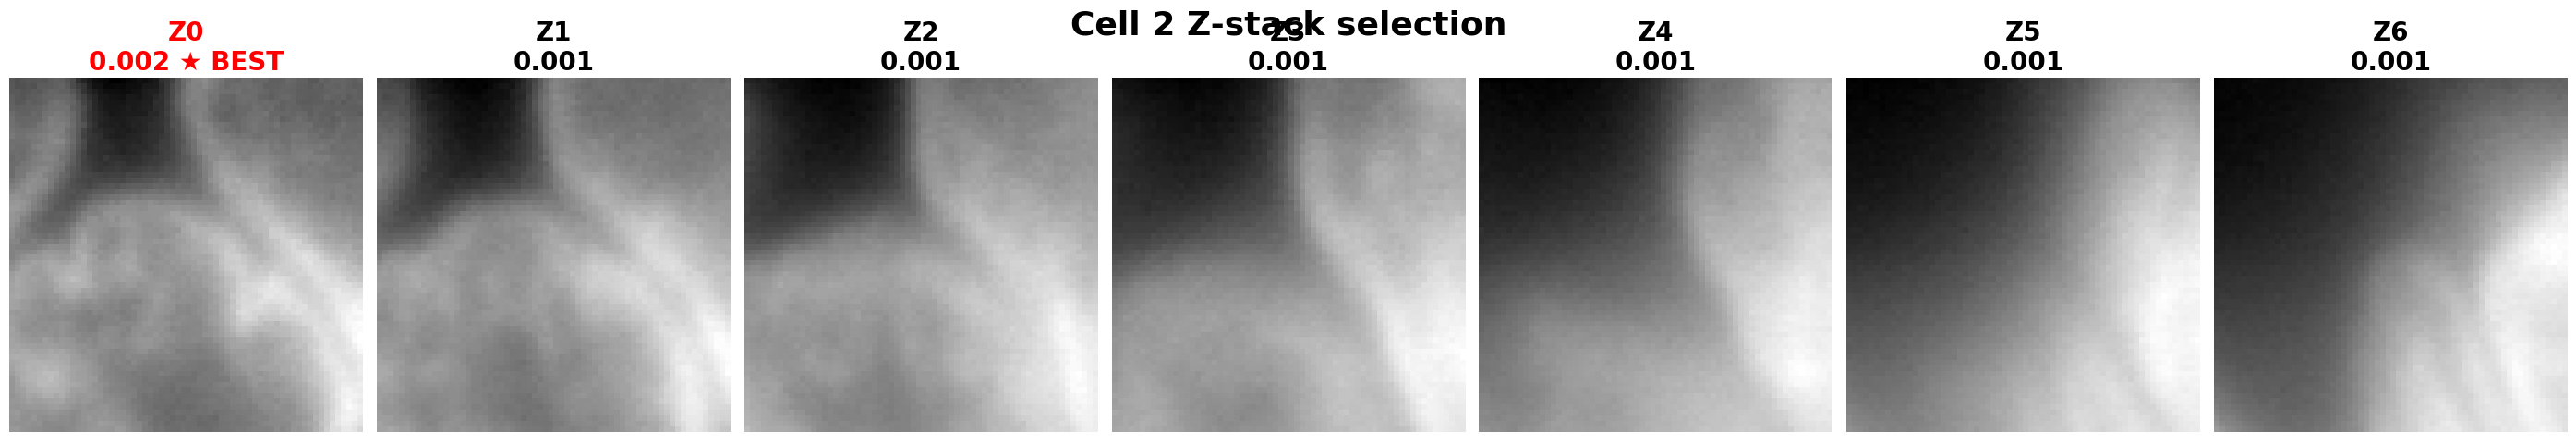

In [14]:
def plot_z_selection(cell_index):
    x, y = cell_coords[cell_index]
    x_px, y_px = microns_to_pixels(x, y)

    patches = [extract_patch(img, x_px, y_px) for img in z_images]
    scores = [laplacian_variance(p) for p in patches]
    best_idx = int(np.argmax(scores))

    n = len(patches)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    axes = np.array(axes)

    for i, patch in enumerate(patches):
        ax = axes[i]

        ax.imshow(patch, cmap='gray')
        ax.axis('off')

        is_best = (i == best_idx)

        ax.set_title(
            f"Z{i}\n{scores[i]:.3f}" + (" ★ BEST" if is_best else ""),
            fontsize=20,                 # 🔥 BIG FONT
            color="red" if is_best else "black",
            fontweight="bold"
        )

        if is_best:
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(5)   # thicker border

    fig.suptitle(
        f"Cell {cell_index} Z-stack selection",
        fontsize=26,                  # 🔥 BIG TITLE
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

plot_z_selection(2)

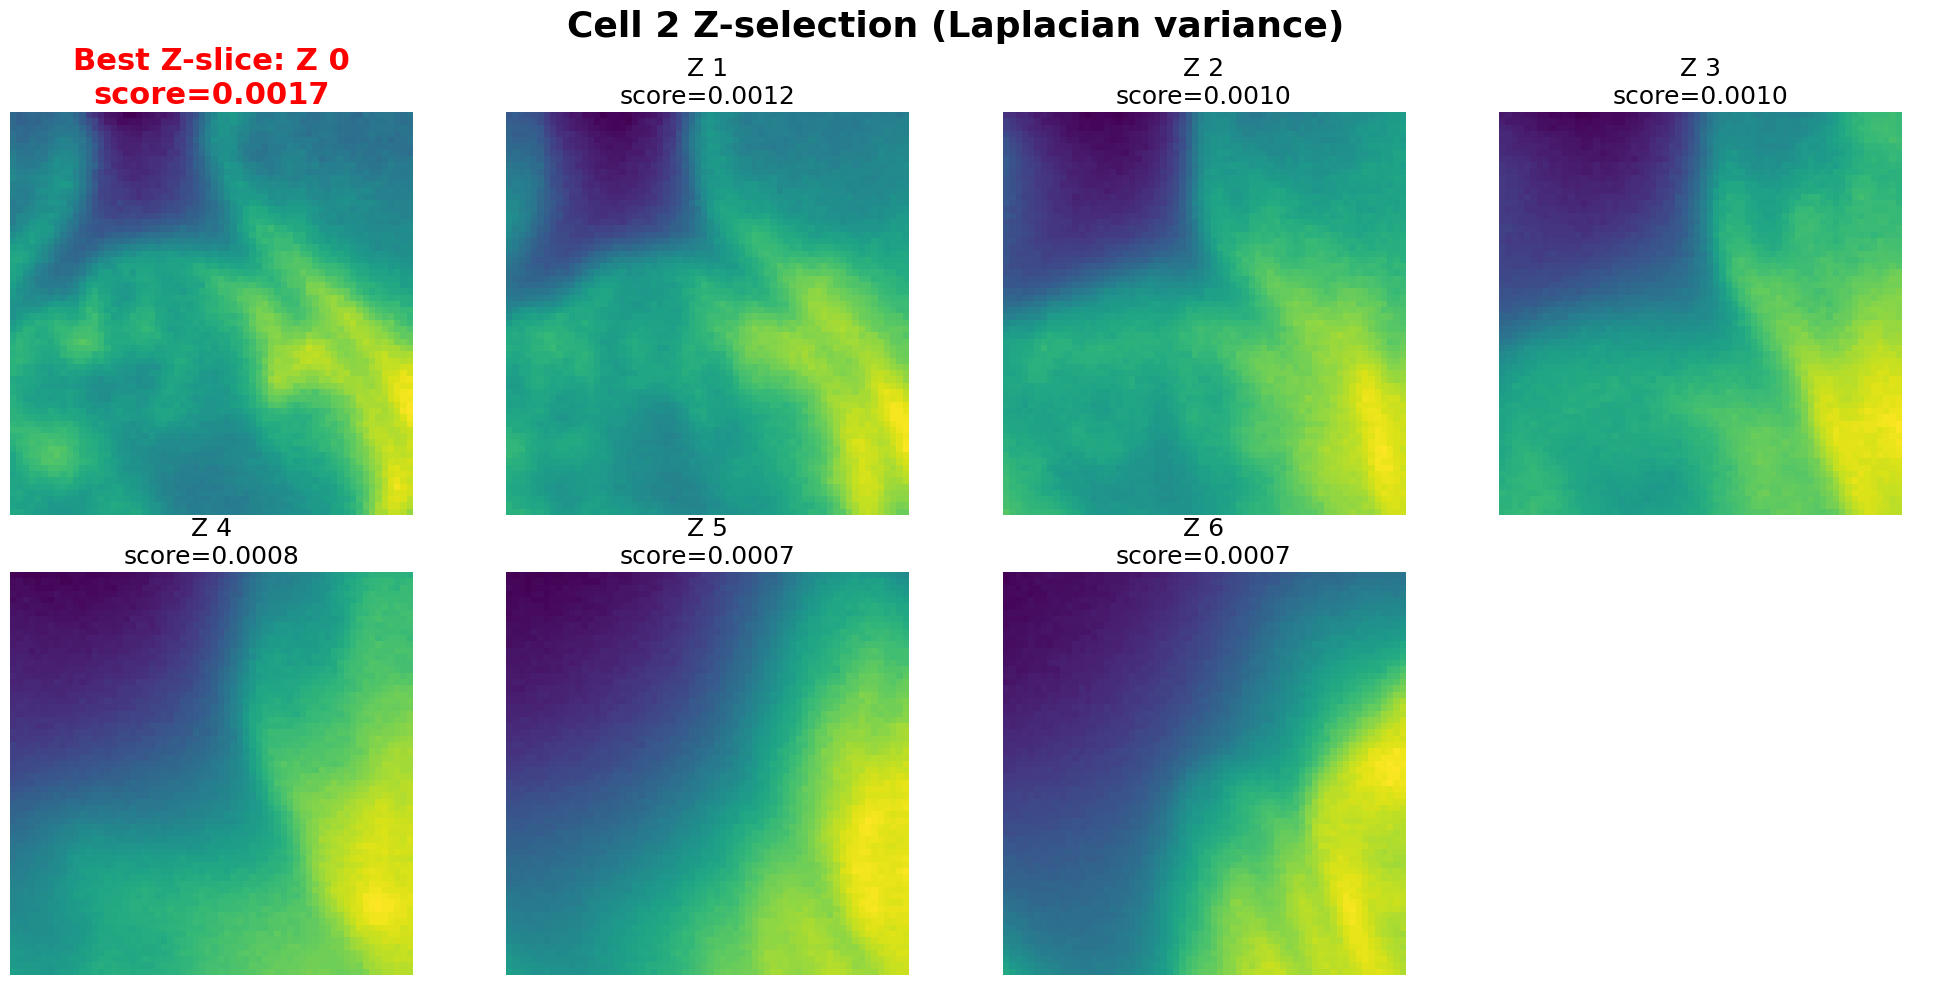

In [23]:
def plot_z_selection(cell_index):
    x, y = cell_coords[cell_index]
    x_px, y_px = microns_to_pixels(x, y)

    patches = [extract_patch(img, x_px, y_px) for img in z_images]
    scores = [laplacian_variance(p) for p in patches]
    best_idx = int(np.argmax(scores))

    cols = 4
    rows = int(np.ceil(len(patches) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for i, patch in enumerate(patches):
        ax = axes[i]
        ax.imshow(patch)
        ax.axis("off")

        if i == best_idx:
            ax.set_title(
                f"Best Z-slice: Z {i}\nscore={scores[i]:.4f}",
                color="red",
                fontsize=22,      #  increased from 14
                fontweight="bold"
            )
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(4)
        else:
            ax.set_title(
                f"Z {i}\nscore={scores[i]:.4f}",
                fontsize=18       #  increased from 12
            )

    for j in range(len(patches), len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"Cell {cell_index} Z-selection (Laplacian variance)",
        fontsize=26,          #  bigger title
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

plot_z_selection(2)

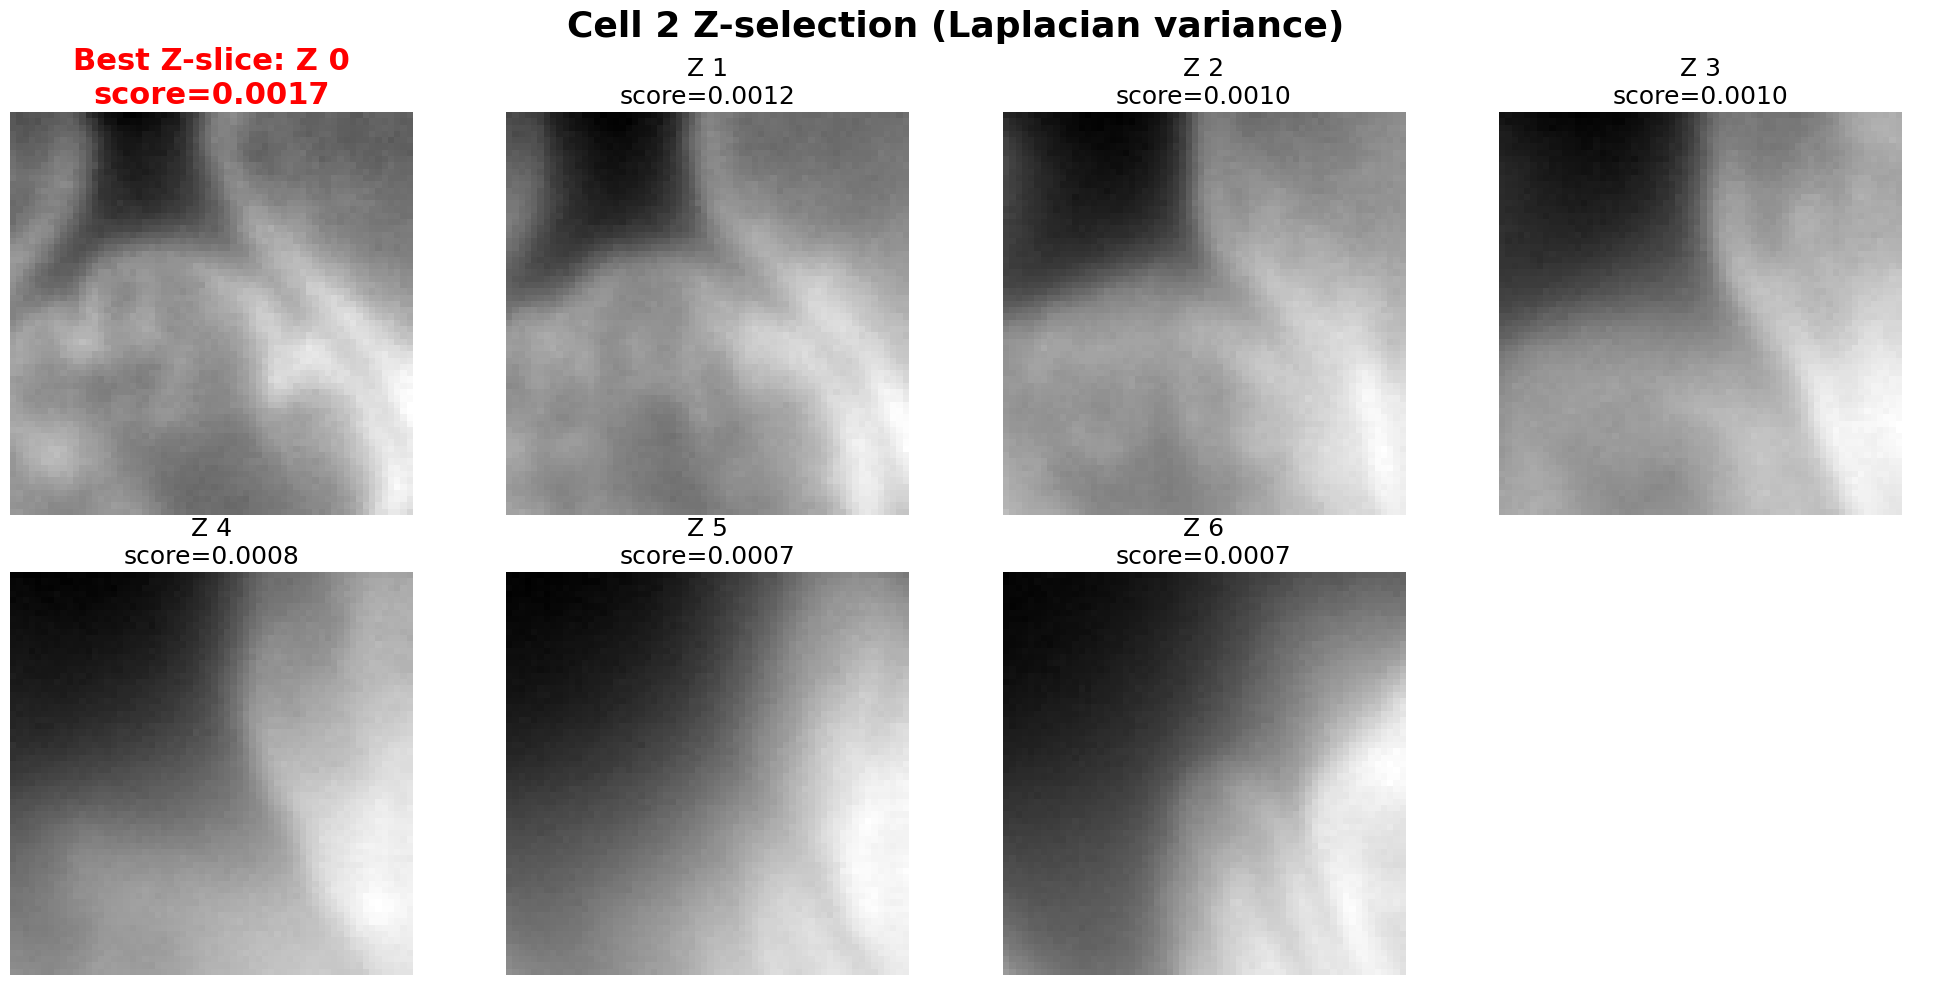

In [24]:
def plot_z_selection(cell_index):
    x, y = cell_coords[cell_index]
    x_px, y_px = microns_to_pixels(x, y)

    patches = [extract_patch(img, x_px, y_px) for img in z_images]
    scores = [laplacian_variance(p) for p in patches]
    best_idx = int(np.argmax(scores))

    cols = 4
    rows = int(np.ceil(len(patches) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for i, patch in enumerate(patches):
        ax = axes[i]

        #  FORCE GRAYSCALE DISPLAY
        ax.imshow(patch, cmap='gray')
        ax.axis("off")

        if i == best_idx:
            ax.set_title(
                f"Best Z-slice: Z {i}\nscore={scores[i]:.4f}",
                color="red",
                fontsize=22,
                fontweight="bold"
            )
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(4)
        else:
            ax.set_title(
                f"Z {i}\nscore={scores[i]:.4f}",
                fontsize=18
            )

    for j in range(len(patches), len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"Cell {cell_index} Z-selection (Laplacian variance)",
        fontsize=26,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

plot_z_selection(2)

In [26]:
from tifffile import TiffFile

file_path = Z_SLICE_FILES[0]  # check first DAPI file

with TiffFile(file_path) as tif:
    img = tif.asarray(out='memmap')
    
print("Shape:", img.shape)
print("Dtype:", img.dtype)
print("Number of dimensions:", img.ndim)

# Interpretation
if img.ndim == 2:
    print("Single-channel (grayscale)")
elif img.ndim == 3:
    if img.shape[-1] == 3:
        print(" Likely RGB (3 channels)")
    elif img.shape[-1] == 1:
        print(" Single-channel with explicit channel dimension")
    else:
        print(" Multi-channel image with", img.shape[-1], "channels")
else:
    print(" Unexpected format")

Shape: (43083, 65824)
Dtype: uint16
Number of dimensions: 2
Single-channel (grayscale)


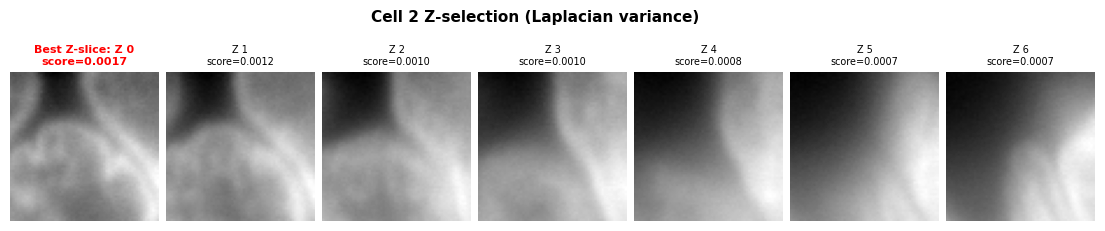

In [32]:
def plot_z_selection(cell_index):
    x, y = cell_coords[cell_index]
    x_px, y_px = microns_to_pixels(x, y)

    patches = [extract_patch(img, x_px, y_px) for img in z_images]
    scores = [laplacian_variance(p) for p in patches]
    best_idx = int(np.argmax(scores))

    n = len(patches)

    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.2))

    if n == 1:
        axes = [axes]

    for i, patch in enumerate(patches):
        ax = axes[i]

        ax.imshow(patch, cmap='gray')
        ax.axis("off")

        if i == best_idx:
            ax.set_title(
                f"Best Z-slice: Z {i}\nscore={scores[i]:.4f}",
                color="red",
                fontsize=8,
                fontweight="bold"
            )
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(2)
        else:
            ax.set_title(
                f"Z {i}\nscore={scores[i]:.4f}",
                fontsize=7
            )

    # Separate title (no overlap)
    fig.suptitle(
        f"Cell {cell_index} Z-selection (Laplacian variance)",
        fontsize=11,
        fontweight="bold",
        y=1.08   # 🔥 pushes title above plots
    )

    # tight horizontal layout
    plt.subplots_adjust(wspace=0.05, top=0.8)

    plt.show()


plot_z_selection(2)

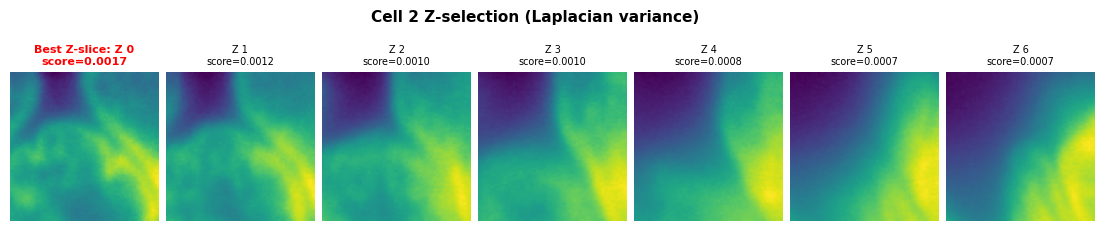

In [33]:
def plot_z_selection(cell_index):
    x, y = cell_coords[cell_index]
    x_px, y_px = microns_to_pixels(x, y)

    patches = [extract_patch(img, x_px, y_px) for img in z_images]
    scores = [laplacian_variance(p) for p in patches]
    best_idx = int(np.argmax(scores))

    n = len(patches)

    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.2))

    if n == 1:
        axes = [axes]

    for i, patch in enumerate(patches):
        ax = axes[i]

        # removed cmap='gray'
        ax.imshow(patch)
        ax.axis("off")

        if i == best_idx:
            ax.set_title(
                f"Best Z-slice: Z {i}\nscore={scores[i]:.4f}",
                color="red",
                fontsize=8,
                fontweight="bold"
            )
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(2)
        else:
            ax.set_title(
                f"Z {i}\nscore={scores[i]:.4f}",
                fontsize=7
            )

    fig.suptitle(
        f"Cell {cell_index} Z-selection (Laplacian variance)",
        fontsize=11,
        fontweight="bold",
        y=1.08
    )

    plt.subplots_adjust(wspace=0.05, top=0.8)

    plt.show()


plot_z_selection(2)